In [60]:
1+1

2

## Basic chatbot using graphAPI

In [61]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END

from langgraph.graph.message import add_messages #this is a reducer
#the work of a reducer is to append information inside state rather than replace it


 

In [62]:
class State(TypedDict):
    messages:Annotated[list,add_messages] #here the messagesmake thelist and it uses reducer



In [63]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [64]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-120b")


In [65]:
#this bascally is my node functionality 
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [66]:
graph_builder=StateGraph(State)

#adding node
graph_builder.add_node("llmchatbot", chatbot) 

#adding edge
graph_builder.add_edge(START, 'llmchatbot')
graph_builder.add_edge('llmchatbot', END)

In [67]:
#compile graph

graph=graph_builder.compile()

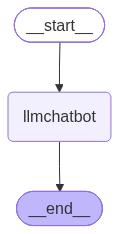

In [68]:
## visual of grapoh

from IPython.display import Image,display

display(Image(graph.get_graph().draw_mermaid_png()))

In [69]:
#needed to put mesages to invoke 
response = graph.invoke({"messages":"Yo"})

In [70]:
response['messages'][-1].content

'Hey there! What’s up? 😄'

In [71]:
#more ways to stream 
for event in graph.stream({"messages":"hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hey there! I’m doing great, thanks for asking. How can I help you today?


## Chatbot with tool


In [72]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 3)
response = tool.invoke("what is langgraph")


In [73]:
response

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cr

In [74]:
#custom function

def multiply(a:int , b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [75]:
tools = [tool,multiply]

In [76]:
llm_with_tools = llm.bind_tools(tools)

In [77]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x12c694550>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x12c694f50>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted res

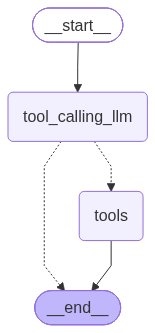

In [84]:
#stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#state
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#node
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#edges 
builder.add_edge(START,"tool_calling_llm") #tool
#here i need conditional edge that whether to call tool or not 
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))



In [87]:
response = graph.invoke({"messages":"what is current job market"})

In [88]:
response['messages'][-1].content

'{"query": "current job market 2024 2025 2026 overview employment trends", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.jobspikr.com/blog/current-employment-trends", "title": "Current Employment Trends: Key Insights for Job Seekers", "content": "Title: Current Employment Trends: Key Insights for Job Seekers\\n# Current Employment Trends in 2024: Insights and Implications for Job Seekers and Employers. Current Employment Trends: Key Insights for Job Seekers. Current Employment Trends: Key Insights for Job Seekers. Understanding the current employment trends in 2024 is crucial for both job seekers and employers to stay competitive and make informed decisions. This article provides a comprehensive overview of the most significant employment trends this year and discusses how these trends are impacting various industries, job seekers, and employers. Current Employment Trends in 2024: Insights and Implications for Job Seekers and Employers. Cur

In [89]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is current job market
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_c5bcfe8d-54ef-4adb-a9ee-67d6085ee00a)
 Call ID: fc_c5bcfe8d-54ef-4adb-a9ee-67d6085ee00a
  Args:
    query: current job market 2024 2025 2026 overview employment trends
    search_depth: advanced
    time_range: year
================================= Tool Message =================================
Name: tavily_search

{"query": "current job market 2024 2025 2026 overview employment trends", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.jobspikr.com/blog/current-employment-trends", "title": "Current Employment Trends: Key Insights for Job Seekers", "content": "Title: Current Employment Trends: Key Insights for Job Seekers\n# Current Employment Trends in 2024: Insights and Implications for Job Seekers and Employers. Current Em

In [90]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_34568363-0d2a-4596-a92f-6c52d9b6ff27)
 Call ID: fc_34568363-0d2a-4596-a92f-6c52d9b6ff27
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [91]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_bf3f6fb9-ac3f-4faa-a71a-69cc9e739e64)
 Call ID: fc_bf3f6fb9-ac3f-4faa-a71a-69cc9e739e64
  Args:
    query: latest AI news
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "Sprout Social released its Trellis artificial intelligence agent for enterprise social media management. The software applies conversational artificial intelligence models to query historical social performance data, surface shift